In [9]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# 1. Load the Dataset
df = pd.read_csv('RideTrust_Survey_Data.csv')

# 2. Data Preparation for Model 1
# Create Gender Dummy (1 if Female, 0 if Male)
df['Female_Dummy'] = np.where(df['Gender'] == 'Female', 1, 0)

# CRITICAL FIX: Clean the 'Income' strings so they don't break the formula parser
# Replace special characters with safe tokens (e.g. '<' -> 'lt_', '>' -> 'gt_'), then replace spaces/hyphens with underscores,
# and '+' with '_plus' so column names are valid Python identifiers for Patsy/statsmodels.
df['Income_Clean'] = (df['Income']
					  .str.replace('<', 'lt_', regex=False)
					  .str.replace('>', 'gt_', regex=False)
					  .str.replace(' ', '_', regex=False)
					  .str.replace('-', '_', regex=False)
					  .str.replace('+', '_plus', regex=False))

# Create Income Dummies from the clean column, drop the first to avoid the Dummy Variable Trap
income_dummies = pd.get_dummies(df['Income_Clean'], prefix='Income', drop_first=True)

# Convert boolean dummy columns to integers (0 and 1) for statsmodels
income_dummies = income_dummies.astype(int)
df = pd.concat([df, income_dummies], axis=1)

# Apply Logarithmic Transformation for the Dependent Variable (WTP)
df['Log_WTP'] = np.log(df['Q17_WTP_Max_Price'])

# 3. Model Definition and Execution
print("MODEL 1: OLS REGRESSION (Estimating the Trust Premium)\n")

# Construct the formula dynamically to include all clean income dummies
income_cols = ' + '.join(income_dummies.columns)

# The asterisk (*) automatically creates the interaction term AND includes the individual variables
ols_formula = f"Log_WTP ~ Q7_Safety_Fear * Female_Dummy + {income_cols}"

print(f"Formula being used: {ols_formula}\n")

# Fit the OLS model
ols_model = smf.ols(formula=ols_formula, data=df).fit()

# Print the Summary Table
print(ols_model.summary())

MODEL 1: OLS REGRESSION (Estimating the Trust Premium)

Formula being used: Log_WTP ~ Q7_Safety_Fear * Female_Dummy + Income_15_25_LPA + Income_25_LPA_plus + Income_5_10_LPA + Income_lt__5_LPA

                            OLS Regression Results                            
Dep. Variable:                Log_WTP   R-squared:                       0.746
Model:                            OLS   Adj. R-squared:                  0.736
Method:                 Least Squares   F-statistic:                     78.36
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           3.19e-52
Time:                        19:27:57   Log-Likelihood:                 91.064
No. Observations:                 195   AIC:                            -166.1
Df Residuals:                     187   BIC:                            -139.9
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                

In [10]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Load Dataset
df = pd.read_csv('RideTrust_Survey_Data.csv')

# Defining High Intent strictly as a score of 7 to avoid Perfect Separation
df['High_Intent_7'] = np.where(df['Q20_Download_Intent'] == 7, 1, 0)

print("\nMODEL 2: LOGIT REGRESSION (Estimating Adoption Propensity)\n")

# Define Independent Variables (X) for Logit
logit_features = ['Q12_Verified', 'Q11_Zero_Cancel', 'Trips_Per_Month']
X_logit = df[logit_features]

# Add a constant (Intercept) to the model
X_logit = sm.add_constant(X_logit)

# Define Dependent Variable (Y) for Logit
Y_logit = df['High_Intent_7']

# Fit the Logit model using Maximum Likelihood Estimation (MLE)
logit_model = sm.Logit(Y_logit, X_logit).fit()

# Print the Summary Table
print(logit_model.summary())


MODEL 2: LOGIT REGRESSION (Estimating Adoption Propensity)

Optimization terminated successfully.
         Current function value: 0.526446
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:          High_Intent_7   No. Observations:                  195
Model:                          Logit   Df Residuals:                      191
Method:                           MLE   Df Model:                            3
Date:                Wed, 08 Apr 2026   Pseudo R-squ.:                  0.2006
Time:                        19:27:57   Log-Likelihood:                -102.66
converged:                       True   LL-Null:                       -128.42
Covariance Type:            nonrobust   LLR p-value:                 3.793e-11
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -5.6825      1.061

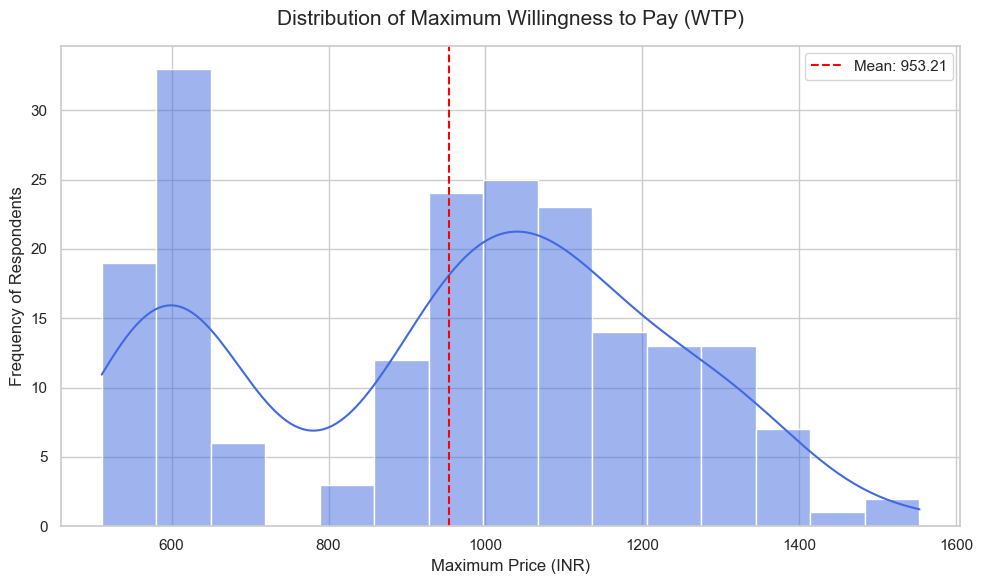

/var/folders/tb/gby8qbdj30n37_xj_qyxg0_h0000gn/T/ipykernel_34927/2341389968.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gender', y='Q17_WTP_Max_Price', data=df, palette='Set2', width=0.5)


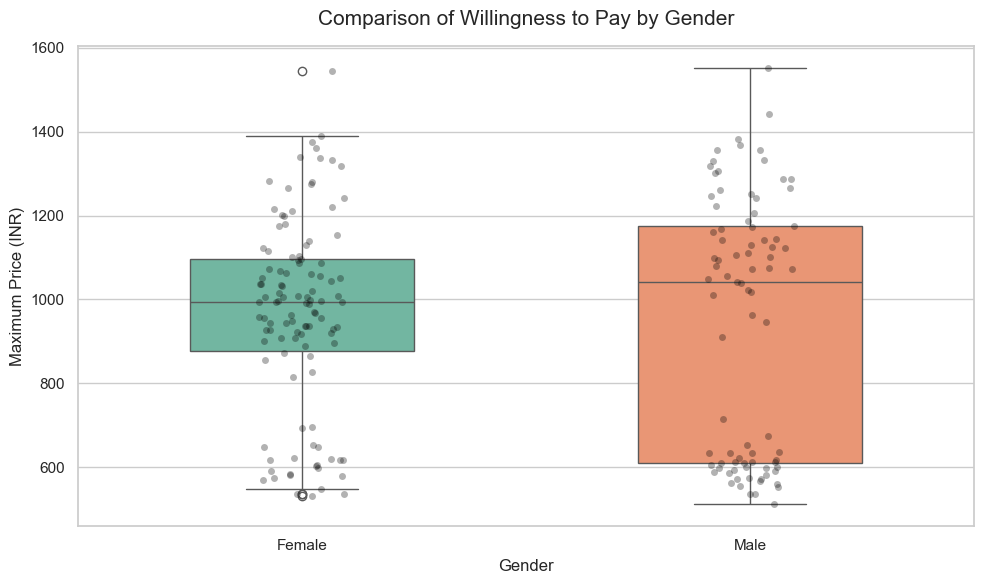

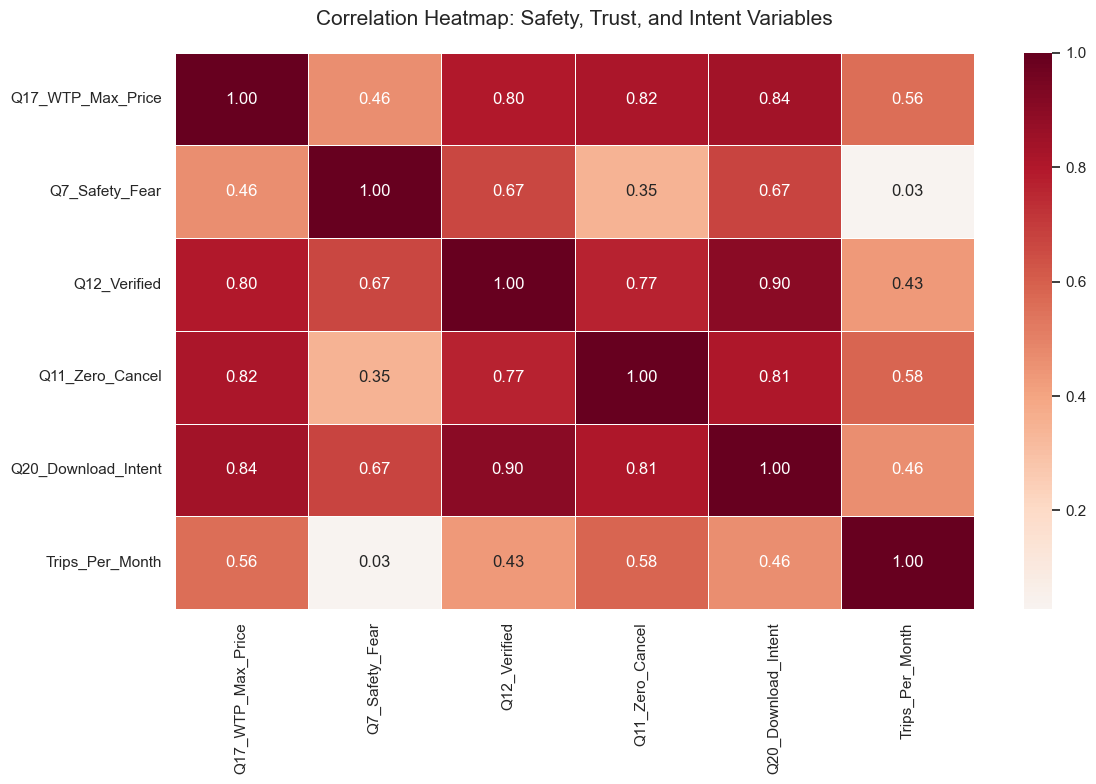

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure dataframe 'df' is available; if not, load it
try:
    df  # noqa: F401
except NameError:
    import pandas as pd
    df = pd.read_csv('RideTrust_Survey_Data.csv')

# Set the visual style for professional reports
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ---------------------------------------------------------
# 1. HISTOGRAM: Distribution of Max Willingness to Pay
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.histplot(df['Q17_WTP_Max_Price'], kde=True, color='royalblue', bins=15)
plt.title('Distribution of Maximum Willingness to Pay (WTP)', fontsize=15, pad=15)
plt.xlabel('Maximum Price (INR)', fontsize=12)
plt.ylabel('Frequency of Respondents', fontsize=12)
plt.axvline(df['Q17_WTP_Max_Price'].mean(), color='red', linestyle='--', label=f"Mean: {df['Q17_WTP_Max_Price'].mean():.2f}")
plt.legend()
plt.tight_layout()
plt.savefig('wtp_histogram.png', dpi=300) # Saves as a high-res image
plt.show()

# ---------------------------------------------------------
# 2. BOXPLOT: WTP Grouped by Gender
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.boxplot(x='Gender', y='Q17_WTP_Max_Price', data=df, palette='Set2', width=0.5)
sns.stripplot(x='Gender', y='Q17_WTP_Max_Price', data=df, color='black', alpha=0.3) # Adds individual data points for transparency
plt.title('Comparison of Willingness to Pay by Gender', fontsize=15, pad=15)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Maximum Price (INR)', fontsize=12)
plt.tight_layout()
plt.savefig('wtp_gender_boxplot.png', dpi=300)
plt.show()

# ---------------------------------------------------------
# 3. HEATMAP: Correlation Matrix
# ---------------------------------------------------------
plt.figure(figsize=(12, 8))

# Selecting the most relevant variables for the heatmap
corr_cols = ['Q17_WTP_Max_Price', 'Q7_Safety_Fear', 'Q12_Verified', 
             'Q11_Zero_Cancel', 'Q20_Download_Intent', 'Trips_Per_Month']
corr_matrix = df[corr_cols].corr()

# Plotting the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap: Safety, Trust, and Intent Variables', fontsize=15, pad=20)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300)
plt.show()

In [13]:
import pandas as pd
import numpy as np

# 1. Load the Dataset ONCE
df = pd.read_csv('RideTrust_Survey_Data.csv')

# ==========================================
# 2. TRANSFORMATIONS FOR MODEL 1 (OLS)
# ==========================================

# Create Gender Dummy
df['Female_Dummy'] = np.where(df['Gender'] == 'Female', 1, 0)

# Clean Income Strings
df['Income_Clean'] = (df['Income']
                      .str.replace('<', 'lt_', regex=False)
                      .str.replace('>', 'gt_', regex=False)
                      .str.replace(' ', '_', regex=False)
                      .str.replace('-', '_', regex=False)
                      .str.replace('+', '_plus', regex=False))

# Create Income Dummies and merge them into the dataframe
income_dummies = pd.get_dummies(df['Income_Clean'], prefix='Income', drop_first=True)
income_dummies = income_dummies.astype(int)
df = pd.concat([df, income_dummies], axis=1)

# Apply Logarithmic Transformation to WTP
df['Log_WTP'] = np.log(df['Q17_WTP_Max_Price'])

# ==========================================
# 3. TRANSFORMATIONS FOR MODEL 2 (LOGIT)
# ==========================================

# Defining High Intent strictly as a score of 7
df['High_Intent_7'] = np.where(df['Q20_Download_Intent'] == 7, 1, 0)

# ==========================================
# 4. EXPORT THE FINAL CONSOLIDATED DATASET
# ==========================================

# Export to Excel
df.to_excel('RideTrust_Processed_Data_FINAL.xlsx', index=False)

print(f"Success! The file 'RideTrust_Processed_Data_FINAL.xlsx' has been saved.")
print(f"It contains a total of {len(df.columns)} columns.")

Success! The file 'RideTrust_Processed_Data_FINAL.xlsx' has been saved.
It contains a total of 33 columns.
